Step 1 — Prepare the transaction data

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("online_retail_II.csv", encoding="latin1")

# Clean data
basket_df = df.copy()

basket_df = basket_df.dropna(subset=["Customer ID"])

# Remove cancelled orders
basket_df = basket_df[
    ~basket_df["Invoice"].astype(str).str.startswith("C")
]

# Keep only positive quantities
basket_df = basket_df[basket_df["Quantity"] > 0]

# Convert InvoiceDate
basket_df["InvoiceDate"] = pd.to_datetime(
    basket_df["InvoiceDate"]
)

# Convert Customer ID
basket_df["Customer ID"] = basket_df["Customer ID"].astype(int)

print("Rows after cleaning:", len(basket_df))
print("Unique orders:", basket_df["Invoice"].nunique())
print("Unique products:", basket_df["Description"].nunique())

C:\Users\Bikash Mahato\AppData\Local\Temp\ipykernel_25500\1908453553.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  basket_df["InvoiceDate"] = pd.to_datetime(


Rows after cleaning: 397925
Unique orders: 18536
Unique products: 3877


In [3]:
basket_df[["Invoice", "StockCode", "Description", "Quantity"]].head(10)

,Invoice,StockCode,Description,Quantity
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,71053,WHITE METAL LANTERN,6
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6
7,536366,22633,HAND WARMER UNION JACK,6
8,536366,22632,HAND WARMER RED POLKA DOT,6
9,536368,22960,JAM MAKING SET WITH JARS,6


Step 2 — Create product baskets

In [4]:
# Create a basket for each order
baskets = (
    basket_df.groupby("Invoice")["Description"]
    .apply(lambda x: sorted(set(x)))
    .reset_index(name="Products")
)

print("Number of baskets:", len(baskets))

baskets.head()

Number of baskets: 18536


,Invoice,Products
0,536365,"[CREAM CUPID HEARTS COAT HANGER, GLASS STAR FR..."
1,536366,"[HAND WARMER RED POLKA DOT, HAND WARMER UNION ..."
2,536367,"[ASSORTED COLOUR BIRD ORNAMENT, BOX OF 6 ASSOR..."
3,536368,"[BLUE COAT RACK PARIS FASHION, JAM MAKING SET ..."
4,536369,[BATH BUILDING BLOCK WORD]


In [5]:
baskets.iloc[0]

Invoice                                                536365
Products    [CREAM CUPID HEARTS COAT HANGER, GLASS STAR FR...
Name: 0, dtype: object

Step 3 — Generate product pairs

In [6]:
from itertools import combinations

In [7]:
pair_list = []

for products in baskets["Products"]:
    if len(products) >= 2:
        pairs = combinations(products, 2)

        for pair in pairs:
            pair_list.append(pair)

print("Total product pairs:", len(pair_list))

Total product pairs: 9115423


In [8]:
pairs_df = pd.DataFrame(
    pair_list,
    columns=["Product 1", "Product 2"]
)

pairs_df.head(10)

,Product 1,Product 2
0,CREAM CUPID HEARTS COAT HANGER,GLASS STAR FROSTED T-LIGHT HOLDER
1,CREAM CUPID HEARTS COAT HANGER,KNITTED UNION FLAG HOT WATER BOTTLE
2,CREAM CUPID HEARTS COAT HANGER,RED WOOLLY HOTTIE WHITE HEART.
3,CREAM CUPID HEARTS COAT HANGER,SET 7 BABUSHKA NESTING BOXES
4,CREAM CUPID HEARTS COAT HANGER,WHITE HANGING HEART T-LIGHT HOLDER
5,CREAM CUPID HEARTS COAT HANGER,WHITE METAL LANTERN
6,GLASS STAR FROSTED T-LIGHT HOLDER,KNITTED UNION FLAG HOT WATER BOTTLE
7,GLASS STAR FROSTED T-LIGHT HOLDER,RED WOOLLY HOTTIE WHITE HEART.
8,GLASS STAR FROSTED T-LIGHT HOLDER,SET 7 BABUSHKA NESTING BOXES
9,GLASS STAR FROSTED T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER


Step 4 — Count how frequently each pair occurs

In [9]:
pair_counts = (
    pairs_df
    .value_counts()
    .reset_index(name="Order Count")
)

pair_counts.head(10)

,Product 1,Product 2,Order Count
0,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,546
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,541
2,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,530
3,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,523
4,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,517
5,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,468
6,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,467
7,LUNCH BAG BLACK SKULL.,LUNCH BAG PINK POLKADOT,464
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,463
9,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,460


In [10]:
pair_counts = pair_counts.sort_values(
    "Order Count",
    ascending=False
).reset_index(drop=True)

pair_counts.head(20)

,Product 1,Product 2,Order Count
0,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,546
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,541
2,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,530
3,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,523
4,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,517
5,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,468
6,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,467
7,LUNCH BAG BLACK SKULL.,LUNCH BAG PINK POLKADOT,464
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,463
9,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,460


Step 5 — Calculate Pair Frequency %

In [11]:
total_orders = baskets["Invoice"].nunique()

pair_counts["Pair Frequency %"] = (
    pair_counts["Order Count"] / total_orders * 100
).round(2)

pair_counts.head(20)

,Product 1,Product 2,Order Count,Pair Frequency %
0,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,546,2.95
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,541,2.92
2,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,530,2.86
3,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,523,2.82
4,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,517,2.79
5,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,468,2.52
6,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,467,2.52
7,LUNCH BAG BLACK SKULL.,LUNCH BAG PINK POLKADOT,464,2.50
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,463,2.50
9,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,460,2.48


Step 6 — Create the Top 20 Product Pairs Table

In [12]:
top_pairs = pair_counts.head(20).copy()

top_pairs = top_pairs[
    ["Product 1", "Product 2", "Order Count", "Pair Frequency %"]
]

top_pairs

,Product 1,Product 2,Order Count,Pair Frequency %
0,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,546,2.95
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,541,2.92
2,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,530,2.86
3,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,523,2.82
4,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,517,2.79
5,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,468,2.52
6,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,467,2.52
7,LUNCH BAG BLACK SKULL.,LUNCH BAG PINK POLKADOT,464,2.50
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,463,2.50
9,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,460,2.48


In [14]:
top_pairs

,Product Pair,Order Count,Pair Frequency %
0,JUMBO BAG PINK POLKADOT + JUMBO BAG RED RETROSPOT,546,2.95
1,GREEN REGENCY TEACUP AND SAUCER + ROSES REGENC...,541,2.92
2,ALARM CLOCK BAKELIKE GREEN + ALARM CLOCK BAKEL...,530,2.86
3,LUNCH BAG PINK POLKADOT + LUNCH BAG RED RETROSPOT,523,2.82
4,LUNCH BAG BLACK SKULL. + LUNCH BAG RED RETROSPOT,517,2.79
5,WOODEN FRAME ANTIQUE WHITE + WOODEN PICTURE F...,468,2.52
6,LUNCH BAG RED RETROSPOT + LUNCH BAG SPACEBOY D...,467,2.52
7,LUNCH BAG BLACK SKULL. + LUNCH BAG PINK POLKADOT,464,2.50
8,GARDENERS KNEELING PAD CUP OF TEA + GARDENERS...,463,2.50
9,GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY...,460,2.48


Step 7 — Visualize the Top 10 Product Pairs

In [15]:
top_10_pairs = pair_counts.head(10).copy()

top_10_pairs["Product Pair"] = (
    top_10_pairs["Product 1"]
    + " + "
    + top_10_pairs["Product 2"]
)

top_10_pairs = top_10_pairs[
    ["Product Pair", "Order Count", "Pair Frequency %"]
]

top_10_pairs

,Product Pair,Order Count,Pair Frequency %
0,JUMBO BAG PINK POLKADOT + JUMBO BAG RED RETROSPOT,546,2.95
1,GREEN REGENCY TEACUP AND SAUCER + ROSES REGENC...,541,2.92
2,ALARM CLOCK BAKELIKE GREEN + ALARM CLOCK BAKEL...,530,2.86
3,LUNCH BAG PINK POLKADOT + LUNCH BAG RED RETROSPOT,523,2.82
4,LUNCH BAG BLACK SKULL. + LUNCH BAG RED RETROSPOT,517,2.79
5,WOODEN FRAME ANTIQUE WHITE + WOODEN PICTURE F...,468,2.52
6,LUNCH BAG RED RETROSPOT + LUNCH BAG SPACEBOY D...,467,2.52
7,LUNCH BAG BLACK SKULL. + LUNCH BAG PINK POLKADOT,464,2.50
8,GARDENERS KNEELING PAD CUP OF TEA + GARDENERS...,463,2.50
9,GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY...,460,2.48


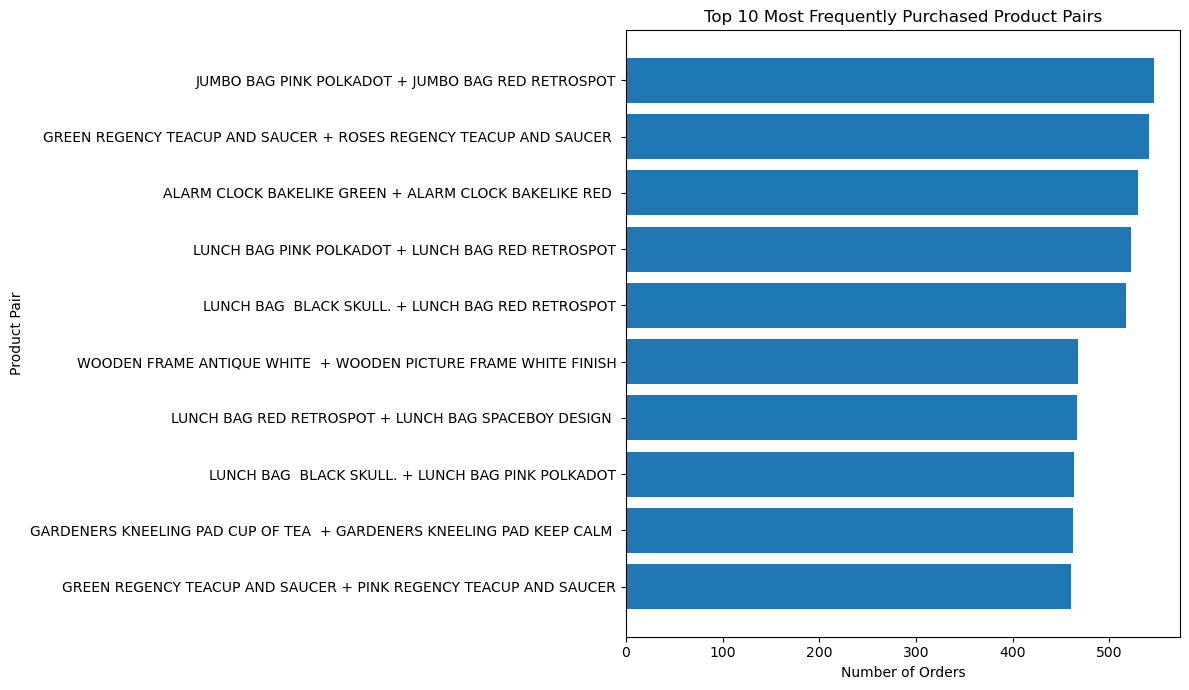

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_pairs["Product Pair"],
    top_10_pairs["Order Count"]
)

plt.xlabel("Number of Orders")
plt.ylabel("Product Pair")
plt.title("Top 10 Most Frequently Purchased Product Pairs")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Step 8 — Generate product recommendations

In [17]:
recommendations = pair_counts.head(20).copy()

recommendations["Recommendation"] = (
    "Promote "
    + recommendations["Product 1"]
    + " with "
    + recommendations["Product 2"]
)

recommendations[
    [
        "Product 1",
        "Product 2",
        "Order Count",
        "Pair Frequency %",
        "Recommendation"
    ]
]

,Product 1,Product 2,Order Count,Pair Frequency %,Recommendation
0,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,546,2.95,Promote JUMBO BAG PINK POLKADOT with JUMBO BAG...
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,541,2.92,Promote GREEN REGENCY TEACUP AND SAUCER with R...
2,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,530,2.86,Promote ALARM CLOCK BAKELIKE GREEN with ALARM ...
3,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,523,2.82,Promote LUNCH BAG PINK POLKADOT with LUNCH BAG...
4,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,517,2.79,Promote LUNCH BAG BLACK SKULL. with LUNCH BAG...
5,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,468,2.52,Promote WOODEN FRAME ANTIQUE WHITE with WOODE...
6,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,467,2.52,Promote LUNCH BAG RED RETROSPOT with LUNCH BAG...
7,LUNCH BAG BLACK SKULL.,LUNCH BAG PINK POLKADOT,464,2.50,Promote LUNCH BAG BLACK SKULL. with LUNCH BAG...
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,463,2.50,Promote GARDENERS KNEELING PAD CUP OF TEA wit...
9,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,460,2.48,Promote GREEN REGENCY TEACUP AND SAUCER with P...


Find the most commonly paired products

In [18]:
top_pair_products = pd.concat([
    pair_counts.head(20)["Product 1"],
    pair_counts.head(20)["Product 2"]
]).value_counts()

top_pair_products.head(10)

LUNCH BAG RED RETROSPOT              7
JUMBO BAG RED RETROSPOT              3
LUNCH BAG PINK POLKADOT              3
LUNCH BAG  BLACK SKULL.              2
LUNCH BAG CARS BLUE                  2
PINK REGENCY TEACUP AND SAUCER       2
GREEN REGENCY TEACUP AND SAUCER      2
ROSES REGENCY TEACUP AND SAUCER      2
WOODEN PICTURE FRAME WHITE FINISH    1
LUNCH BAG WOODLAND                   1
Name: count, dtype: int64

Step 9 — Create a simple recommendation function

In [19]:
def recommend_products(product_name, top_n=5):

    recommendations = pair_counts[
        (pair_counts["Product 1"] == product_name) |
        (pair_counts["Product 2"] == product_name)
    ].copy()

    recommendations["Recommended Product"] = np.where(
        recommendations["Product 1"] == product_name,
        recommendations["Product 2"],
        recommendations["Product 1"]
    )

    return recommendations[
        [
            "Recommended Product",
            "Order Count",
            "Pair Frequency %"
        ]
    ].head(top_n)

In [20]:
recommend_products("LUNCH BAG RED RETROSPOT")

,Recommended Product,Order Count,Pair Frequency %
3,LUNCH BAG PINK POLKADOT,523,2.82
4,LUNCH BAG BLACK SKULL.,517,2.79
6,LUNCH BAG SPACEBOY DESIGN,467,2.52
10,LUNCH BAG CARS BLUE,458,2.47
13,LUNCH BAG SUKI DESIGN,450,2.43


Step 10 — Final Day 29 Analysis

Final results
Your dataset after cleaning:
Metric	Result
Transaction rows	397,925
Unique orders	18,536
Unique products	3,877
Product pairs generated	9,115,423


Top product combinations identified
Your analysis found strong associations such as:
1. Jumbo Bag Pink Polkadot + Jumbo Bag Red Retrospot
2. Green Regency Teacup and Saucer + Roses Regency Teacup and Saucer
3. Alarm Clock Bakelike Green + Alarm Clock Bakelike Red
4. Lunch Bag Pink Polkadot + Lunch Bag Red Retrospot
5. Lunch Bag Black Skull + Lunch Bag Red Retrospot
6. Wooden Frame Antique White + Wooden Picture Frame White Finish
7. Lunch Bag Red Retrospot + Lunch Bag Spaceboy Design
8. Lunch Bag Black Skull + Lunch Bag Pink Polkadot
9. Gardeners Kneeling Pad Cup of Tea + Gardeners Kneeling Pad Keep Calm
10. Green Regency Teacup and Saucer + Pink Regency Teacup and Saucer
Business recommendations
Based on these associations, the business could:
1. Create product bundles
For example:
Jumbo Bag Pink Polkadot + Jumbo Bag Red Retrospot

could be offered as a bundle.
2. Use cross-selling
If a customer purchases:
Lunch Bag Red Retrospot

the system can recommend related lunch-bag products that frequently appear with it.
3. Improve product recommendations
The frequently purchased-together pairs can be used as the foundation for a simple recommendation system.
4. Optimize product placement
Frequently associated products could be displayed near each other in an online store.
5. Create complementary promotions
Related products such as the Regency teacup and saucer combinations could be promoted together

Step 11 — Save your final results

In [21]:
top_pairs.to_csv(
    "Day_29_Top_Product_Pairs.csv",
    index=False
)

print("File saved successfully.")

File saved successfully.


In [22]:
pair_counts.to_csv(
    "Day_29_All_Product_Pairs.csv",
    index=False
)

print("Complete pair analysis saved successfully.")

Complete pair analysis saved successfully.
